<a href="https://colab.research.google.com/github/550tealeaves/DATA-70500-working-with-data/blob/main/NY_Sports_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GOAL - The most important skill of Week 5: every task has TWO versions — one in SQL and one in Python. You'll write both and compare the results. By the end of this week you'll be able to use either tool interchangeably and know when each one is the right choice.

## 1. Load dataset

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ── YANKEES BATTING (2026, through ~15 games) ───────────────────
yank_bat = [
  # name,               pos,  avg,   obp,   slg,   ops,   hr, rbi, g
  ('Ben Rice',          '1B',  .342,  .421,  .589,  1.010, 4,  12,  15),
  ('Giancarlo Stanton', 'DH',  .326,  .398,  .543,  .941,  1,  7,   13),
  ('Aaron Judge',       'CF',  .224,  .341,  .449,  .790,  3,  7,   15),
  ('Cody Bellinger',    'RF',  .222,  .301,  .389,  .690,  1,  5,   14),
  ('Amed Rosario',      'SS',  .289,  .318,  .422,  .740,  2,  6,   15),
  ('Oswaldo Cabrera',   '3B',  .241,  .298,  .362,  .660,  1,  4,   13),
  ('Austin Wells',      'C',   .198,  .276,  .341,  .617,  1,  3,   12),
  ('Trent Grisham',     'LF',  .211,  .295,  .316,  .611,  0,  2,   11),
]
bat_cols = ['name','pos','avg','obp','slg','ops','hr','rbi','games']
df_yank_bat = pd.DataFrame(yank_bat, columns=bat_cols)

# ── YANKEES PITCHING (2026 starters + relievers) ────────────────
yank_pit = [
  # name,              role,      w, l, era,  whip, ip,   k,  bb
  ('Max Fried',        'Starter', 2, 0, 1.35, 0.90, 26.2, 28, 5),
  ('Cam Schlittler',   'Starter', 2, 1, 1.62, 1.01, 22.1, 24, 7),
  ('Ryan Weathers',    'Starter', 1, 1, 2.81, 1.18, 16.0, 14, 8),
  ('Will Warren',      'Starter', 1, 1, 3.07, 1.22, 14.2, 13, 6),
  ('Jake Bird',        'Reliever',1, 0, 1.80, 0.95, 10.0, 12, 3),
  ('Fernando Cruz',    'Reliever',1, 0, 2.35, 1.10,  7.2, 9,  2),
  ('Clay Holmes',      'Closer',  0, 0, 3.12, 1.28,  8.2, 11, 4),
]
pit_cols = ['name','role','wins','losses','era','whip','ip','k','bb']
df_yank_pit = pd.DataFrame(yank_pit, columns=pit_cols)

# ── KNICKS PLAYERS (2025-26 season averages) ────────────────────
knicks_players = [
  # name,                 pos, ppg,  rpg, apg, spg, bpg, fg_pct, min
  ('Jalen Brunson',       'G',  26.0, 3.3, 6.8, 0.9, 0.2, 0.481, 34.9),
  ('Karl-Anthony Towns',  'C',  20.1, 11.9,3.0, 0.9, 0.5, 0.499, 31.1),
  ('OG Anunoby',          'F',  17.0, 5.3, 2.2, 1.6, 0.7, 0.486, 33.0),
  ('Mikal Bridges',       'F',  14.7, 4.1, 3.9, 1.3, 0.8, 0.488, 33.3),
  ('Josh Hart',           'F',   8.1, 7.5, 4.9, 1.1, 0.2, 0.506, 29.8),
  ('Miles McBride',       'G',  12.9, 2.8, 3.1, 0.8, 0.1, 0.451, 26.4),
  ('Mitchell Robinson',   'C',   4.2, 8.8, 0.8, 0.3, 1.2, 0.621, 18.9),
  ('Jose Alvarado',       'G',   7.8, 2.1, 3.7, 1.0, 0.2, 0.441, 22.1),
]
kp_cols = ['name','pos','ppg','rpg','apg','spg','bpg','fg_pct','mpg']
df_knicks = pd.DataFrame(knicks_players, columns=kp_cols)

# ── KNICKS LAST 10 GAMES ────────────────────────────────────────
knicks_games = [
  # opponent,           pts_for, pts_against, home_away, win
  ('Raptors',            112, 95,  'Home', 1),
  ('Celtics',            108, 104, 'Away', 1),
  ('76ers',               99, 91,  'Home', 1),
  ('Heat',               101, 88,  'Away', 1),
  ('Bucks',               97, 103, 'Home', 0),
  ('Hawks',              115, 107, 'Away', 1),
  ('Hornets',             88,  92, 'Home', 0),
  ('Cavaliers',          104,  98, 'Away', 1),
  ('Magic',              109,  97, 'Home', 1),
  ('Nets',               121,  88, 'Home', 1),
]
kg_cols = ['opponent','pts_for','pts_against','home_away','win']
df_knicks_games = pd.DataFrame(knicks_games, columns=kg_cols)

# ── LOAD ALL INTO SQLITE ────────────────────────────────────────
conn = sqlite3.connect(':memory:')
df_yank_bat.to_sql('yankees_batting',  conn, index=False, if_exists='replace')
df_yank_pit.to_sql('yankees_pitching', conn, index=False, if_exists='replace')
df_knicks.to_sql('knicks_players',     conn, index=False, if_exists='replace')
df_knicks_games.to_sql('knicks_games', conn, index=False, if_exists='replace')
print('All four tables loaded!')

All four tables loaded!


In [ ]:
print(yank_bat, '\n')
print(yank_pit, '\n')
print(knicks_players, '\n')
print(knicks_games, '\n')

[('Ben Rice', '1B', 0.342, 0.421, 0.589, 1.01, 4, 12, 15), ('Giancarlo Stanton', 'DH', 0.326, 0.398, 0.543, 0.941, 1, 7, 13), ('Aaron Judge', 'CF', 0.224, 0.341, 0.449, 0.79, 3, 7, 15), ('Cody Bellinger', 'RF', 0.222, 0.301, 0.389, 0.69, 1, 5, 14), ('Amed Rosario', 'SS', 0.289, 0.318, 0.422, 0.74, 2, 6, 15), ('Oswaldo Cabrera', '3B', 0.241, 0.298, 0.362, 0.66, 1, 4, 13), ('Austin Wells', 'C', 0.198, 0.276, 0.341, 0.617, 1, 3, 12), ('Trent Grisham', 'LF', 0.211, 0.295, 0.316, 0.611, 0, 2, 11)] 

[('Max Fried', 'Starter', 2, 0, 1.35, 0.9, 26.2, 28, 5), ('Cam Schlittler', 'Starter', 2, 1, 1.62, 1.01, 22.1, 24, 7), ('Ryan Weathers', 'Starter', 1, 1, 2.81, 1.18, 16.0, 14, 8), ('Will Warren', 'Starter', 1, 1, 3.07, 1.22, 14.2, 13, 6), ('Jake Bird', 'Reliever', 1, 0, 1.8, 0.95, 10.0, 12, 3), ('Fernando Cruz', 'Reliever', 1, 0, 2.35, 1.1, 7.2, 9, 2), ('Clay Holmes', 'Closer', 0, 0, 3.12, 1.28, 8.2, 11, 4)] 

[('Jalen Brunson', 'G', 26.0, 3.3, 6.8, 0.9, 0.2, 0.481, 34.9), ('Karl-Anthony Towns',

## Download CSV file

In [ ]:
# Convert to CSV & download
df_yank_bat.to_csv('yank_bat.csv', index=False)
df_yank_pit.to_csv('yank_pit.csv', index=False)
df_knicks.to_csv('knicks_players.csv', index=False)
df_knicks_games.to_csv('knicks_games.csv', index=False)
from google.colab import files
files.download('yank_bat.csv')
files.download('yank_pit.csv')
files.download('knicks_players.csv')
files.download('knicks_games.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Write the SQL version first — run it and check the output. Then write the Python version to match the same result.
- Add a comment at the end of each task with one sentence: 'SQL was better here because...' or 'Python was easier here because...' This reflection is the most important part.

## Show all Yankees batters with OPS above 0.700

In [2]:
# -- SQL version
pd.read_sql_query('''
    SELECT name, pos, avg, ops
    FROM yankees_batting
    WHERE ops > 0.700
    ORDER BY ops DESC
''', conn)

,name,pos,avg,ops
0,Ben Rice,1B,0.342,1.010
1,Giancarlo Stanton,DH,0.326,0.941
2,Aaron Judge,CF,0.224,0.790
3,Amed Rosario,SS,0.289,0.740


In [3]:
# Python version
df_yank_bat[
    df_yank_bat['ops'] > 0.700
][['name','pos','avg','ops']].sort_values('ops',
    ascending=False)

,name,pos,avg,ops
0,Ben Rice,1B,0.342,1.010
1,Giancarlo Stanton,DH,0.326,0.941
2,Aaron Judge,CF,0.224,0.790
4,Amed Rosario,SS,0.289,0.740


## Filter & Sort — Find the Yankees' power hitters
- Find all Yankees batters with 2 or more home runs this season. Show their **name, position, home runs, RBI, and OPS**. Sort by home runs descending.

In [4]:
# -- SQL version
pd.read_sql_query('''
    SELECT name, pos, hr, rbi, ops
    FROM yankees_batting
    WHERE hr >= 2
    ORDER BY hr DESC
''', conn)

,name,pos,hr,rbi,ops
0,Ben Rice,1B,4,12,1.01
1,Aaron Judge,CF,3,7,0.79
2,Amed Rosario,SS,2,6,0.74


- SQL was much easier to use

In [5]:
# -- Python version
df_yank_bat[
    df_yank_bat['hr'] >= 2
][['name', 'pos', 'hr', 'rbi', 'ops']].sort_values('hr', ascending=False)

,name,pos,hr,rbi,ops
0,Ben Rice,1B,4,12,1.01
2,Aaron Judge,CF,3,7,0.79
4,Amed Rosario,SS,2,6,0.74


Python seems understandable but I have a tough time rememberin the differnt functions

## Aggregation — Knicks starters vs bench comparison
- Create a new column called 'role' that labels players as 'Starter' if they average 30+ minutes, or 'Bench' if under 30 minutes. Then calculate the average PPG, RPG, and FG% for each role group. Which group is more efficient?

In [6]:
#
pd.read_sql_query('''
SELECT name, mpg,
  CASE
    WHEN mpg >= 30 THEN 'Starter'
    ELSE 'Bench'
      END AS 'Role'
  FROM knicks_players
''', conn)

,name,mpg,Role
0,Jalen Brunson,34.9,Starter
1,Karl-Anthony Towns,31.1,Starter
2,OG Anunoby,33.0,Starter
3,Mikal Bridges,33.3,Starter
4,Josh Hart,29.8,Bench
5,Miles McBride,26.4,Bench
6,Mitchell Robinson,18.9,Bench
7,Jose Alvarado,22.1,Bench


In [7]:
# -- SQL--
# Create the new column first and then get the averages and group by role
pd.read_sql_query('''
SELECT
  CASE
    WHEN mpg >= 30 THEN 'Starter'
    ELSE 'Bench'
  END AS role,
  AVG(ppg) AS 'avg ppg',
  AVG(rpg) AS 'avg rpg',
  AVG(fg_pct) AS 'avg fg%'
FROM knicks_players
GROUP BY role;
''', conn)

,role,avg ppg,avg rpg,avg fg%
0,Bench,8.25,5.30,0.50475
1,Starter,19.45,6.15,0.48850


In [8]:
# -- Python version --
# Use np.where that uses if/else logic - assigns value based on if True or False

# adds col role to the df_knicks & w/in if mpg >= 30, assign Starter. If else, Bench
df_knicks['role'] = np.where(
    df_knicks['mpg'] >= 30, 'Starter', 'Bench'
)
# Use groupby to obtain avg of ppg, rpg, fg% by role
df_knicks.groupby('role')[['ppg', 'rpg', 'fg_pct']].mean()

,ppg,rpg,fg_pct
role,,,
Bench,8.25,5.30,0.50475
Starter,19.45,6.15,0.48850


- Starters are overall better than the Bench players, which makes sense based on what a starter is vs a bench player
- In terms of pure code, the python is probably a little easier (less things to write) but I think the SQL code is a bit more intuitive.

In [9]:
# -- Python version --
# Use np.where that uses if/else logic - assigns value based on if True or False

# adds col role to the df_knicks & w/in if mpg >= 30, assign Starter. If else, Bench
df_knicks['role'] = np.where(
    df_knicks['mpg'] >= 30, 'Starter', 'Bench'
)
print(df_knicks[['name', 'role']])
df_knicks.groupby('role')[['ppg', 'rpg', 'fg_pct']].mean()

                 name     role
0       Jalen Brunson  Starter
1  Karl-Anthony Towns  Starter
2          OG Anunoby  Starter
3       Mikal Bridges  Starter
4           Josh Hart    Bench
5       Miles McBride    Bench
6   Mitchell Robinson    Bench
7       Jose Alvarado    Bench


,ppg,rpg,fg_pct
role,,,
Bench,8.25,5.30,0.50475
Starter,19.45,6.15,0.48850


## JOIN — Link Yankees batting & pitching on a team summary
- Calculate one combined team summary row showing: average batter OPS, average pitcher ERA, average pitcher WHIP, and total team home runs.
- In SQL join the two tables on a shared literal.
- In Python use concat and groupby. What does this tell you about the 2026 Yankees balance?

In [10]:
# SQL: cross-table summary
# CROSS JOIN creates cartesian table, combining every row from 1st table w/ every row from 2nd table. Does not need ON clause
# First select all the columns from the one table and then after cross join select the rows in the second table
pd.read_sql_query('''

    SELECT
      ROUND(AVG(b.ops),3)  AS avg_ops,
      ROUND(AVG(p.era),2)  AS avg_era,
      ROUND(AVG(p.whip),2) AS avg_whip,
      SUM(b.hr) AS total_hr
    FROM yankees_batting b
    CROSS JOIN (
        SELECT AVG(era) AS era,
               AVG(whip) AS whip
        FROM yankees_pitching
    ) p
''', conn)


,avg_ops,avg_era,avg_whip,total_hr
0,0.757,2.3,1.09,13


In [11]:
# Python: manual summary dict
summary = {
  'avg_ops': round(
    df_yank_bat['ops'].mean(),3),
  'avg_era': round(
    df_yank_pit['era'].mean(),2),
  'avg_whip':round(
    df_yank_pit['whip'].mean(),2),
  'total_hr': df_yank_bat['hr'].sum()
}
pd.DataFrame([summary])

,avg_ops,avg_era,avg_whip,total_hr
0,0.757,2.3,1.09,13


- I think the actual code from Python seems a little easier to read than SQL but I do not yet have the expertise in Python syntax to remember the order. The SQL code is a little more complex, and I have never done CROSS JOIN, but I think it makes sense.

## Window-style ranking — Rank each Knicks player by PPG
Add a rank column to the Knicks player data showing each player's scoring rank on the team (1 = highest scorer). Show name, PPG, and rank.
- In SQL use ORDER BY with ROW_NUMBER logic.
- In Python use .rank().

In [32]:
# -- SQL version --
pd.read_sql_query('''
SELECT
  name,
  ppg,
  CASE
    WHEN ppg > 20.1 THEN '1'
    WHEN ppg > 17.0 THEN '2'
    WHEN ppg > 14.7 THEN '3'
    WHEN ppg > 14.0 THEN '4'
    WHEN ppg > 10.8 THEN '5'
    WHEN ppg > 8.0 THEN '6'
    WHEN ppg > 7.0 THEN '7'
    WHEN ppg < 7.0 THEN '8'
  END AS scoring_rank
FROM knicks_players
ORDER BY scoring_rank;
''', conn)

,name,ppg,scoring_rank
0,Jalen Brunson,26.0,1
1,Karl-Anthony Towns,20.1,2
2,OG Anunoby,17.0,3
3,Mikal Bridges,14.7,4
4,Miles McBride,12.9,5
5,Josh Hart,8.1,6
6,Jose Alvarado,7.8,7
7,Mitchell Robinson,4.2,8


In [33]:
# SQL: row-number style ranking
pd.read_sql_query('''

    SELECT
        name, ppg,
        ROW_NUMBER() OVER
            (ORDER BY ppg DESC)
            AS scoring_rank
    FROM knicks_players
    ORDER BY ppg DESC

''', conn)


,name,ppg,scoring_rank
0,Jalen Brunson,26.0,1
1,Karl-Anthony Towns,20.1,2
2,OG Anunoby,17.0,3
3,Mikal Bridges,14.7,4
4,Miles McBride,12.9,5
5,Josh Hart,8.1,6
6,Jose Alvarado,7.8,7
7,Mitchell Robinson,4.2,8


In [38]:
# Python: .rank() method
# Create col scoring_rank - takes the ppg col & using rank - it makes the highest ppg start w/ rank 1.
df_knicks['scoring_rank'] = (
  df_knicks['ppg']
  .rank(ascending=False)
  .astype(int)
)

# Select the columns to show and sort by ppg descending order
df_knicks[['name','ppg',
  'scoring_rank']].sort_values('ppg', ascending=False)


,name,ppg,scoring_rank
0,Jalen Brunson,26.0,1
1,Karl-Anthony Towns,20.1,2
2,OG Anunoby,17.0,3
3,Mikal Bridges,14.7,4
5,Miles McBride,12.9,5
4,Josh Hart,8.1,6
7,Jose Alvarado,7.8,7
6,Mitchell Robinson,4.2,8


- I would say that the SQL code was easier to use based on the word doc. But I first tried to create it myself and the code was far more complicated than it needed to be.

## Home vs Away — Knicks performance split
From the Knicks' last 10 games, calculate their average points scored, average points allowed, and win rate at home vs on the road.
- Where do the Knicks perform better?
- Does the data surprise you?

In [40]:
## My code
pd.read_sql_query('''
    SELECT
        AVG(pts_for) AS 'avg_pts_scored',
        AVG(pts_against) AS 'avg_pts_allowed',
        ROUND(AVG(CASE WHEN home_away = 'Home' THEN 1.0 ELSE 0.0 END), 2) AS 'win_rate_home'
    FROM knicks_games
''', conn)

,avg_pts_scored,avg_pts_allowed,win_rate_home
0,105.4,96.3,0.6


In [41]:
# SQL version
pd.read_sql_query('''

    SELECT
        home_away,
        COUNT(*) AS games,
        ROUND(AVG(pts_for),1)
            AS avg_pts_scored,
        ROUND(AVG(pts_against),1)
            AS avg_pts_allowed,
        ROUND(AVG(win)*100,1)
            AS win_pct
    FROM knicks_games
    GROUP BY home_away

''', conn)


,home_away,games,avg_pts_scored,avg_pts_allowed,win_pct
0,Away,4,107.0,99.3,100.0
1,Home,6,104.3,94.3,66.7


In [46]:
# Python version
# Create group
# aggregate games & create cols avg_scored, avg_allowed, & win_pct calculate the count of wins, the mean of pts scored, and the mean of pts allowed, and win percentage
# round to 2 decimals
df_knicks_games.groupby(
    'home_away'
).agg(
  games=('win','count'),
  avg_scored=(
    'pts_for','mean'),
  avg_allowed=(
    'pts_against','mean'),
  win_pct=('win','mean')
).round(2)


,games,avg_scored,avg_allowed,win_pct
home_away,,,,
Away,4,107.00,99.25,1.00
Home,6,104.33,94.33,0.67


- Knicks perform better away than at home. Is it surprising in the greater sense of basketball? A little because teams typically perform better at home - they have both the crowd and the refs on their side.
But this is the Knicks and they are known for doing things backwards.

- Code in Python seems a little easier than SQL code in terms of writing but I think the groupby still confuses me.

## NULL awareness — Identify any missing values in both datasets
Check both the Yankees batting table and the Knicks players table for any NULL or missing values. Count how many nulls exist per column. This should be clean data — but verifying data quality is always the first step in any real analysis. Compare how SQL and Python express this check.

In [55]:
pd.read_sql_query('''

    SELECT
     SUM(CASE WHEN name IS NULL
         THEN 1 ELSE 0 END) AS null_name,
     SUM(CASE WHEN pos IS NULL
         THEN 1 ELSE 0 END) AS null_pos,
     SUM(CASE WHEN avg IS NULL
         THEN 1 ELSE 0 END) AS null_avg,
      SUM(CASE WHEN obp IS NULL
         THEN 1 ELSE 0 END) AS null_obp,
      SUM(CASE WHEN slg IS NULL
         THEN 1 ELSE 0 END) AS null_slg,
     SUM(CASE WHEN ops IS NULL
         THEN 1 ELSE 0 END) AS null_ops,
     SUM(CASE WHEN hr IS NULL
         THEN 1 ELSE 0 END) AS null_hr,
    SUM(CASE WHEN rbi IS NULL
         THEN 1 ELSE 0 END) AS null_rbi,
    SUM(CASE WHEN games IS NULL
         THEN 1 ELSE 0 END) AS null_games
    FROM yankees_batting
''', conn)

,null_name,null_pos,null_avg,null_obp,null_slg,null_ops,null_hr,null_rbi,null_games
0,0,0,0,0,0,0,0,0,0


In [52]:
pd.read_sql_query('''

    SELECT
     SUM(CASE WHEN name IS NULL
         THEN 1 ELSE 0 END) AS null_name,
     SUM(CASE WHEN pos IS NULL
         THEN 1 ELSE 0 END) AS null_pos,
     SUM(CASE WHEN ppg IS NULL
         THEN 1 ELSE 0 END) AS null_ppg,
      SUM(CASE WHEN rpg IS NULL
          THEN 1 ELSE 0 END) AS null_rpg,
      SUM(CASE WHEN apg IS NULL
          THEN 1 ELSE 0 END) AS null_apg,
      SUM(CASE WHEN spg IS NULL
          THEN 1 ELSE 0 END) AS null_spg,
      SUM(CASE WHEN bpg IS NULL
          THEN 1 ELSE 0 END) AS null_bpg,
      SUM(CASE WHEN fg_pct IS NULL
          THEN 1 ELSE 0 END) AS null_fg_pct,
      SUM(CASE WHEN mpg IS NULL
          THEN 1 ELSE 0 END) AS null_mpg
    FROM knicks_players

''', conn)

,null_name,null_pos,null_ppg,null_rpg,null_apg,null_spg,null_bpg,null_fg_pct,null_mpg
0,0,0,0,0,0,0,0,0,0


In [48]:
# Python: one-liner null check

print('Yankees batting:')
print(df_yank_bat
      .isnull().sum())

print('Knicks players:')
print(df_knicks
      .isnull().sum())


Yankees batting:
name     0
pos      0
avg      0
obp      0
slg      0
ops      0
hr       0
rbi      0
games    0
dtype: int64
Knicks players:
name            0
pos             0
ppg             0
rpg             0
apg             0
spg             0
bpg             0
fg_pct          0
mpg             0
role            0
scoring_rank    0
dtype: int64


- Python code was much simpler

# Visualization

## Yankees
Horizontal bar chart of each batter's OPS, colored by position. Sort from highest to lowest. Add a vertical dashed line at the league average OPS (roughly 0.720) so it's easy to see who is above and below average.

## Knicks
Scatter plot of PPG (x-axis) vs FG% (y-axis) for all 8 players, with each dot labeled by the player's name. Size the dots by rebounds per game — bigger rebounders get bigger dots. Add a color for guards vs forwards vs centers.

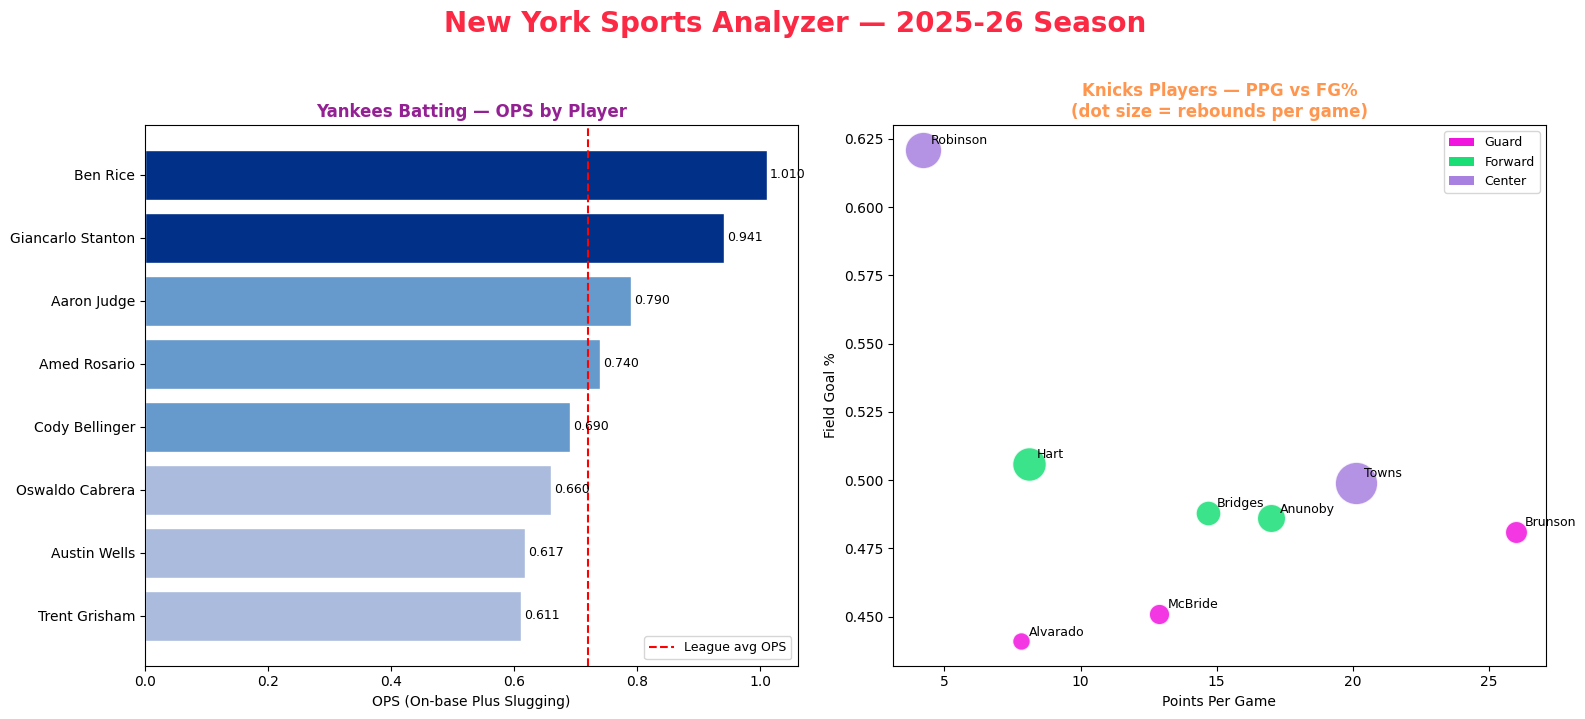

In [68]:
# Task 7 — Grand Finale Chart (starter code — run and customize)
# Starter structure — fill in the chart details
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('New York Sports Analyzer — 2025-26 Season',
             fontsize=20, fontweight='bold', y=1.02, color='#fb2943')

# ── CHART 1: Yankees OPS horizontal bar ─────────────────────────
# Create group by sorting the yank bat df by ops in ascending order
bat_sorted = df_yank_bat.sort_values('ops', ascending=True)
# Assign colors for each position (pos) and assign to variable
colors_bat = {'1B':'#003087','DH':'#003087','CF':'#6699CC',
              'RF':'#6699CC','SS':'#6699CC','3B':'#AABBDD',
              'C':'#AABBDD','LF':'#AABBDD'}
bar_colors = [colors_bat.get(p,'#CCCCCC') for p in bat_sorted['pos']]
ax1.barh(bat_sorted['name'], bat_sorted['ops'], color=bar_colors, edgecolor='white')
ax1.axvline(0.720, color='red', linestyle='--', linewidth=1.5, label='League avg OPS')
ax1.set_xlabel('OPS (On-base Plus Slugging)')
ax1.set_title('Yankees Batting — OPS by Player', fontweight='bold', color='#942193')
ax1.legend(fontsize=9)
for i, v in enumerate(bat_sorted['ops']):
    ax1.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# ── CHART 2: Knicks PPG vs FG% scatter ──────────────────────────
pos_colors = {'G':'#f114de','F':'#19de76','C':'#a880e0'}
for _, row in df_knicks.iterrows():
    ax2.scatter(row['ppg'], row['fg_pct'],
                s=row['rpg']*80,
                color=pos_colors.get(row['pos'],'gray'),
                edgecolors='white', linewidth=1.2, alpha=0.85, zorder=3)
    ax2.annotate(row['name'].split()[-1],
                 (row['ppg'], row['fg_pct']),
                 textcoords='offset points', xytext=(6,4), fontsize=9)
ax2.set_xlabel('Points Per Game')
ax2.set_ylabel('Field Goal %')
ax2.set_title('Knicks Players — PPG vs FG%\n(dot size = rebounds per game)', fontweight='bold', color='#ff964f')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#f114de',label='Guard'),
                   Patch(facecolor='#19de76',label='Forward'),
                   Patch(facecolor='#a880e0',label='Center')]
ax2.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()


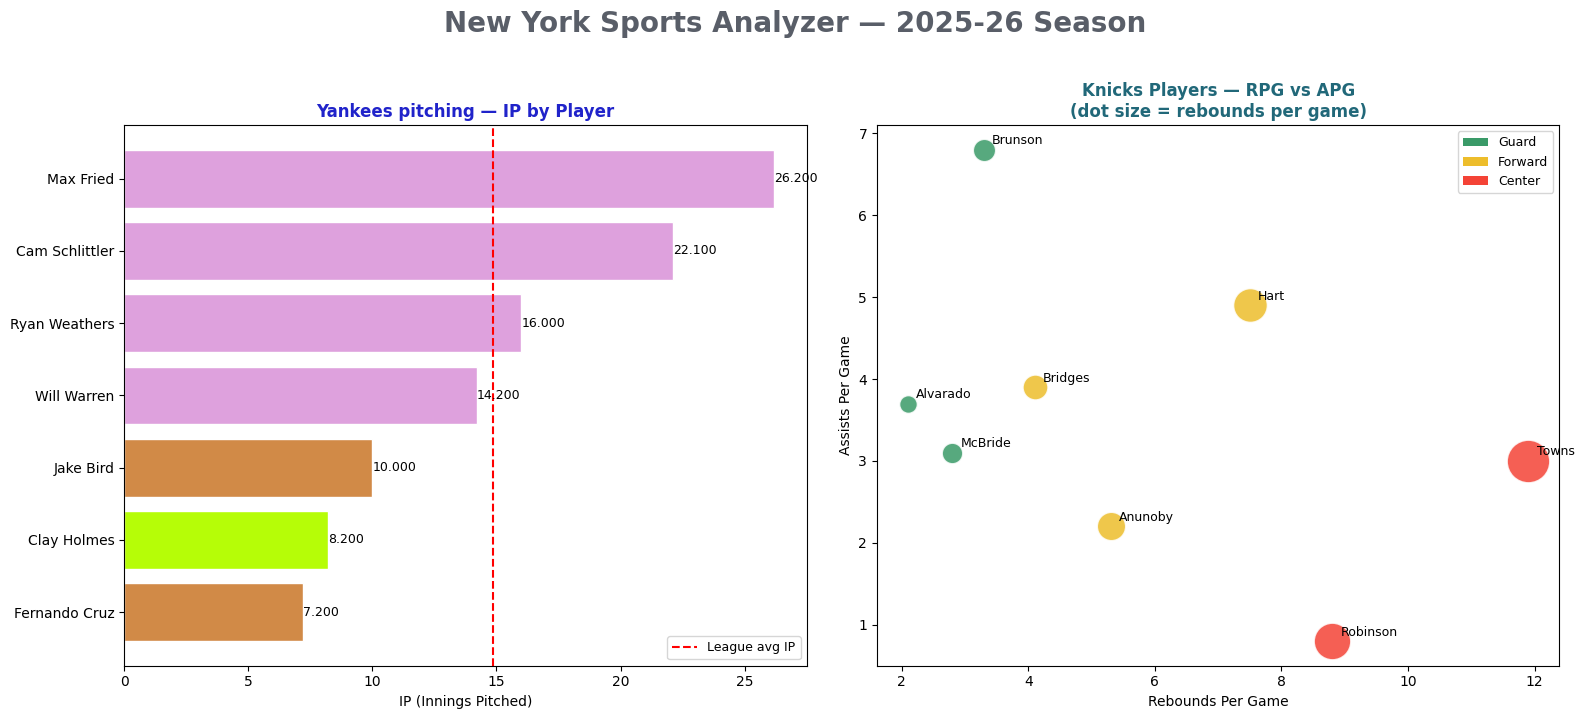

In [98]:
# Task 7 — Grand Finale Chart (starter code — run and customize)
# Starter structure — fill in the chart details
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('New York Sports Analyzer — 2025-26 Season',
             fontsize=20, fontweight='bold', y=1.02, color='#595e68')

# ── CHART 1: Yankees IP horizontal bar ─────────────────────────
# Create group by sorting the yank bat df by ops in ascending order
pit_sorted = df_yank_pit.sort_values('ip', ascending=True)
# Assign colors for each position (pos) and assign to variable
colors_pit = {'Max Fried':'#dea1dd','Cam Schlittler':'#dea1dd',
              'Ryan Weathers':'#dea1dd','Will Warren':'#dea1dd','Jake Bird':'#d18a47',
              'Fernando Cruz':'#d18a47','Clay Holmes':'#b6fd07'}
bar_colors = [colors_pit.get(p,'#CCCCCC') for p in pit_sorted['name']]
ax1.barh(pit_sorted['name'], pit_sorted['ip'], color=bar_colors, edgecolor='white')
ax1.axvline(14.84, color='red', linestyle='--', linewidth=1.5, label='League avg IP')
ax1.set_xlabel('IP (Innings Pitched)')
ax1.set_title('Yankees pitching — IP by Player', fontweight='bold', color='#2023ca')
ax1.legend(fontsize=9)
for i, v in enumerate(pit_sorted['ip']):
    ax1.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# ── CHART 2: Knicks RPG vs APG scatter ──────────────────────────
pos_colors = {'G':'#3a9a68','F':'#edbd2b','C':'#f44336'}
for _, row in df_knicks.iterrows():
    ax2.scatter(row['rpg'], row['apg'],
                s=row['rpg']*80,
                color=pos_colors.get(row['pos'],'gray'),
                edgecolors='white', linewidth=1.2, alpha=0.85, zorder=3)
    ax2.annotate(row['name'].split()[-1],
                 (row['rpg'], row['apg']),
                 textcoords='offset points', xytext=(6,4), fontsize=9)
ax2.set_xlabel('Rebounds Per Game')
ax2.set_ylabel('Assists Per Game')
ax2.set_title('Knicks Players — RPG vs APG\n(dot size = rebounds per game)', fontweight='bold', color='#216879')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3a9a68',label='Guard'),
                   Patch(facecolor='#edbd2b',label='Forward'),
                   Patch(facecolor='#f44336',label='Center')]
ax2.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()


## Reflection


1.   SQL vs Python: For each of the 6 dual tasks, which version felt
more natural and why? Is there a pattern?
- SQL felt more natural in everything except for the NULL
2.   What is one insight from the data that surprised you — about either the Yankees or the Knicks?
- Surprised that the Knicks won 8/10 games
- I don't know the rules of baseball that well so I cannot say what is surprising about the data.
3. If you had one more week, what analysis would you build next?
What data would you need that isn't in these tables?
- Probably would cross reference the teams with either their overall conference
- Maybe analyze how important each player is to their team (how responsible for wins they are)



